# Logistic Regression vs Random Forest for Network Intrusion Detection
CAP4630 Xudong Liu

Team Members
* Juan Alfonso
* Markos Calderon


This notebook contains the complete training, evaluation, and plotting for this study.

## What this notebook does
- loads a CIC-IDS2017 subset
- preprocesses the dataset
- trains two machine learning models
- evaluates both models with standard classification metrics
- Plots relevant information into graphs

## Models compared
- Logistic Regression
- Random Forest

## Outputs for possible application
- processed dataset
- metrics JSON files
- confusion matrix figures
- model comparison figure
- feature importance figure



In [ ]:
# 1. Imports

from pathlib import Path
import json
import time
import zipfile
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)


In [ ]:
# 2. Configuration

USE_GOOGLE_DRIVE = True   # Set to True if CSV is stored in Google Drive
DRIVE_CSV_PATH = "/content/drive/MyDrive/cicids2017_subset.csv"

TARGET_COLUMN = "Label"
BENIGN_LABEL = "BENIGN"
RANDOM_STATE = 42
TEST_SIZE = 0.2

# Output directories in Colab
OUTPUT_DIR = Path("/content/project_outputs")
DATA_DIR = OUTPUT_DIR / "data"
MODELS_DIR = OUTPUT_DIR / "models"
METRICS_DIR = OUTPUT_DIR / "metrics"
FIGURES_DIR = OUTPUT_DIR / "figures"
REPORTS_DIR = OUTPUT_DIR / "reports"

for folder in [OUTPUT_DIR, DATA_DIR, MODELS_DIR, METRICS_DIR, FIGURES_DIR, REPORTS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Output directory:", OUTPUT_DIR)


Output directory: /content/project_outputs


In [ ]:
# 3. Training summary structure

training_summary = {
    "dataset": {},
    "preprocessing": {},
    "training": {},
    "evaluation": {},
    "artifacts": {}
}

training_summary


{'dataset': {},
 'preprocessing': {},
 'training': {},
 'evaluation': {},
 'artifacts': {}}

## Dataset Loading

This section loads the CIC-IDS2017 subset from Google Drive or from a manual upload in Colab.


In [ ]:
# 4. Load dataset

if USE_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")

    raw_csv_path = Path(DRIVE_CSV_PATH)
    if not raw_csv_path.exists():
        raise FileNotFoundError(f"CSV file not found in Google Drive: {raw_csv_path}")

    df_raw = pd.read_csv(raw_csv_path)
else:
    from google.colab import files

    uploaded = files.upload()
    if not uploaded:
        raise ValueError("No file uploaded")

    uploaded_filename = next(iter(uploaded.keys()))
    raw_csv_path = Path("/content") / uploaded_filename
    df_raw = pd.read_csv(raw_csv_path)

print("Loaded dataset from:", raw_csv_path)
print("Raw shape:", df_raw.shape)

training_summary["dataset"] = {
    "raw_file": str(raw_csv_path),
    "raw_shape": list(df_raw.shape),
    "raw_columns_before_cleaning": df_raw.columns.tolist(),
}


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded dataset from: /content/drive/MyDrive/cicids2017_subset.csv
Raw shape: (225745, 79)


## Raw Data Exploration

This section captures the main dataset information needed for the report:
- dataset size
- feature names
- missing values
- label distribution


In [ ]:
# 5. Quick inspection

display(df_raw.head())

print("Columns:")
print(df_raw.columns.tolist())

print("\nRaw data types:")
display(df_raw.dtypes)

print("\nTop missing values:")
display(df_raw.isnull().sum().sort_values(ascending=False).head(20))


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,4.000000e+06,666666.66670,3.0,0.0,3,3,3,3.0,0.0,3,3,0,0.0,0.0,0,0,0,0,0,0,40,0,666666.666700,0.000000,6,6,6.0,0.0,0.0,0,0,0,0,1,0,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,33,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,1.100917e+05,18348.62385,109.0,0.0,109,109,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,9174.311927,9174.311927,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,1,9.0,6.0,6.0,20,0,0,0,0,0,0,1,6,1,6,29,256,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,2.307692e+05,38461.53846,52.0,0.0,52,52,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,19230.769230,19230.769230,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,1,9.0,6.0,6.0,20,0,0,0,0,0,0,1,6,1,6,29,256,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,3.529412e+05,58823.52941,34.0,0.0,34,34,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,29411.764710,29411.764710,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,1,9.0,6.0,6.0,20,0,0,0,0,0,0,1,6,1,6,31,329,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,4.000000e+06,666666.66670,3.0,0.0,3,3,3,3.0,0.0,3,3,0,0.0,0.0,0,0,0,0,0,0,40,0,666666.666700,0.000000,6,6,6.0,0.0,0.0,0,0,0,0,1,0,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,32,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


Columns:
[' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance', 'FIN Flag Count', ' SYN Flag Count', ' RST Flag Count', ' PSH Flag Count', ' ACK Flag Count', ' 

,0
Destination Port,int64
Flow Duration,int64
Total Fwd Packets,int64
Total Backward Packets,int64
Total Length of Fwd Packets,int64
Total Length of Bwd Packets,int64
Fwd Packet Length Max,int64
Fwd Packet Length Min,int64
Fwd Packet Length Mean,float64
Fwd Packet Length Std,float64



Top missing values:


,0
Flow Bytes/s,4
Flow Duration,0
Destination Port,0
Total Backward Packets,0
Total Length of Fwd Packets,0
Total Length of Bwd Packets,0
Total Fwd Packets,0
Fwd Packet Length Max,0
Fwd Packet Length Min,0
Fwd Packet Length Std,0


In [ ]:
# Clean column names for reliable access
df_raw.columns = df_raw.columns.str.strip()

if TARGET_COLUMN not in df_raw.columns:
    possible_targets = [c for c in df_raw.columns if c.strip().lower() in {"label", "attack", "class", "target"}]
    if not possible_targets:
        raise KeyError(
            f"Target column '{TARGET_COLUMN}' was not found after cleaning columns. "
            f"Available columns: {df_raw.columns.tolist()}"
        )
    TARGET_COLUMN = possible_targets[0]

raw_label_counts = df_raw[TARGET_COLUMN].astype(str).str.strip().value_counts()

print("Using target column:", TARGET_COLUMN)
display(raw_label_counts)

training_summary["dataset"]["raw_columns_after_cleaning"] = df_raw.columns.tolist()
training_summary["dataset"]["raw_label_distribution"] = raw_label_counts.to_dict()


Using target column: Label


,count
Label,
DDoS,128027
BENIGN,97718


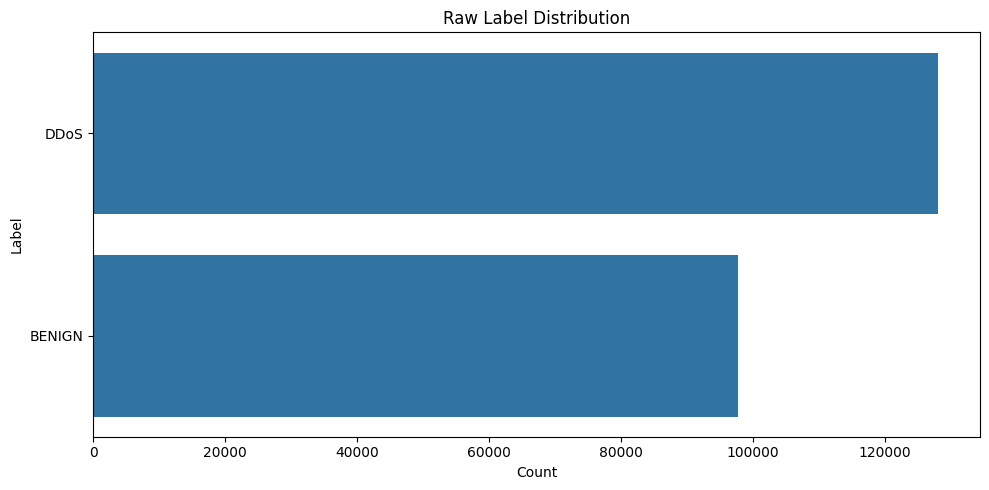

Saved figure: /content/project_outputs/figures/raw_label_distribution.png


In [ ]:
plt.figure(figsize=(10, 5))
sns.countplot(
    y=df_raw[TARGET_COLUMN].astype(str).str.strip(),
    order=df_raw[TARGET_COLUMN].astype(str).str.strip().value_counts().index
)
plt.title("Raw Label Distribution")
plt.xlabel("Count")
plt.ylabel("Label")
plt.tight_layout()

raw_label_plot_path = FIGURES_DIR / "raw_label_distribution.png"
plt.savefig(raw_label_plot_path, dpi=200)
plt.show()

print("Saved figure:", raw_label_plot_path)


## Preprocessing

This section:
- standardizes column names
- removes duplicates
- replaces infinite values
- drops missing values
- converts the target to binary classification
- keeps numeric features only


In [ ]:
# 6. Preprocessing

def preprocess_dataframe(df: pd.DataFrame, target_column: str, benign_label: str = "BENIGN"):
    df = df.copy()

    # Standardize column names
    df.columns = df.columns.str.strip()

    # Remove duplicates
    before_duplicates = len(df)
    df = df.drop_duplicates()
    after_duplicates = len(df)

    # Replace infinite values
    numeric_preview = df.select_dtypes(include=[np.number])
    inf_count_before = int(np.isinf(numeric_preview).sum().sum()) if not numeric_preview.empty else 0
    df.replace([np.inf, -np.inf], np.nan, inplace=True)

    # Missing values
    total_missing_before = int(df.isnull().sum().sum())

    # Drop missing rows
    before_dropna = len(df)
    df = df.dropna()
    after_dropna = len(df)

    # Normalize target and convert to binary
    df[target_column] = df[target_column].astype(str).str.strip()
    df[target_column] = df[target_column].apply(lambda x: 0 if x == benign_label else 1)

    # Keep numeric features only
    feature_df = df.drop(columns=[target_column])
    numeric_df = feature_df.apply(pd.to_numeric, errors="coerce")

    valid_rows = numeric_df.notna().all(axis=1)
    numeric_df = numeric_df.loc[valid_rows].copy()
    numeric_df[target_column] = df.loc[valid_rows, target_column].values

    stats = {
        "rows_removed_duplicates": int(before_duplicates - after_duplicates),
        "infinite_values_detected_before_replacement": inf_count_before,
        "total_missing_values_before_drop": total_missing_before,
        "rows_removed_missing": int(before_dropna - after_dropna),
        "final_rows": int(len(numeric_df)),
        "final_columns": int(numeric_df.shape[1]),
    }

    return numeric_df, stats


df_processed, preprocess_stats = preprocess_dataframe(df_raw, TARGET_COLUMN, BENIGN_LABEL)

print("Preprocessing stats:")
print(json.dumps(preprocess_stats, indent=4))

print("\nProcessed shape:", df_processed.shape)
display(df_processed.head())

processed_csv_path = DATA_DIR / "cicids2017_processed.csv"
df_processed.to_csv(processed_csv_path, index=False)
print("Saved processed dataset to:", processed_csv_path)


Preprocessing stats:
{
    "rows_removed_duplicates": 2633,
    "infinite_values_detected_before_replacement": 56,
    "total_missing_values_before_drop": 60,
    "rows_removed_missing": 30,
    "final_rows": 223082,
    "final_columns": 79
}

Processed shape: (223082, 79)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,4.000000e+06,666666.66670,3.0,0.0,3,3,3,3.0,0.0,3,3,0,0.0,0.0,0,0,0,0,0,0,40,0,666666.666700,0.000000,6,6,6.0,0.0,0.0,0,0,0,0,1,0,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,33,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,0
1,55054,109,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,1.100917e+05,18348.62385,109.0,0.0,109,109,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,9174.311927,9174.311927,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,1,9.0,6.0,6.0,20,0,0,0,0,0,0,1,6,1,6,29,256,0,20,0.0,0.0,0,0,0.0,0.0,0,0,0
2,55055,52,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,2.307692e+05,38461.53846,52.0,0.0,52,52,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,19230.769230,19230.769230,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,1,9.0,6.0,6.0,20,0,0,0,0,0,0,1,6,1,6,29,256,0,20,0.0,0.0,0,0,0.0,0.0,0,0,0
3,46236,34,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,3.529412e+05,58823.52941,34.0,0.0,34,34,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,29411.764710,29411.764710,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,1,9.0,6.0,6.0,20,0,0,0,0,0,0,1,6,1,6,31,329,0,20,0.0,0.0,0,0,0.0,0.0,0,0,0
4,54863,3,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,4.000000e+06,666666.66670,3.0,0.0,3,3,3,3.0,0.0,3,3,0,0.0,0.0,0,0,0,0,0,0,40,0,666666.666700,0.000000,6,6,6.0,0.0,0.0,0,0,0,0,1,0,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,32,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,0


Saved processed dataset to: /content/project_outputs/data/cicids2017_processed.csv


Processed binary label distribution:


,count
Label,
1,128014
0,95068


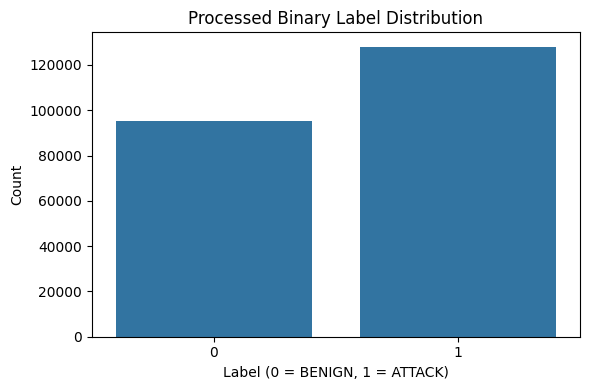

In [ ]:
processed_label_counts = df_processed[TARGET_COLUMN].value_counts()

print("Processed binary label distribution:")
display(processed_label_counts)

plt.figure(figsize=(6, 4))
sns.countplot(x=df_processed[TARGET_COLUMN])
plt.title("Processed Binary Label Distribution")
plt.xlabel("Label (0 = BENIGN, 1 = ATTACK)")
plt.ylabel("Count")
plt.tight_layout()

processed_label_plot_path = FIGURES_DIR / "processed_binary_label_distribution.png"
plt.savefig(processed_label_plot_path, dpi=200)
plt.show()

training_summary["preprocessing"] = {
    "stats": preprocess_stats,
    "processed_shape": list(df_processed.shape),
    "processed_label_distribution": {str(k): int(v) for k, v in processed_label_counts.to_dict().items()},
    "feature_count": int(df_processed.shape[1] - 1),
    "processed_csv_path": str(processed_csv_path),
}


## Train/Test Split

A stratified split is used so the class balance is preserved between the training set and the test set.


In [ ]:
# 7. Train/test split

X = df_processed.drop(columns=[TARGET_COLUMN])
y = df_processed[TARGET_COLUMN]

feature_names = list(X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
print("Feature count:", len(feature_names))

training_summary["training"]["split"] = {
    "X_train_shape": list(X_train.shape),
    "X_test_shape": list(X_test.shape),
    "y_train_shape": list(y_train.shape),
    "y_test_shape": list(y_test.shape),
    "test_size": TEST_SIZE,
    "random_state": RANDOM_STATE,
    "feature_count": len(feature_names),
}


X_train shape: (178465, 78)
X_test shape: (44617, 78)
y_train shape: (178465,)
y_test shape: (44617,)
Feature count: 78


## Model Training

Two models are trained:
- Logistic Regression
- Random Forest


In [ ]:
# 8. Train models

# Logistic Regression with scaling
log_start = time.time()
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_scaled, y_train)
log_duration = time.time() - log_start

# Random Forest
rf_start = time.time()
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight="balanced"
)
rf_model.fit(X_train, y_train)
rf_duration = time.time() - rf_start

training_summary["training"]["models"] = {
    "logistic_regression": {
        "max_iter": 1000,
        "random_state": RANDOM_STATE,
        "training_time_seconds": round(log_duration, 4),
    },
    "random_forest": {
        "n_estimators": 200,
        "random_state": RANDOM_STATE,
        "class_weight": "balanced",
        "training_time_seconds": round(rf_duration, 4),
    },
}

print("Training complete.")
print(json.dumps(training_summary["training"]["models"], indent=4))


Training complete.
{
    "logistic_regression": {
        "max_iter": 1000,
        "random_state": 42,
        "training_time_seconds": 8.3502
    },
    "random_forest": {
        "n_estimators": 200,
        "random_state": 42,
        "class_weight": "balanced",
        "training_time_seconds": 75.099
    }
}


In [ ]:
# 9. Evaluation helper

def evaluate_model(model_name, model, X_eval, y_true, save_prefix):
    y_pred = model.predict(X_eval)

    metrics = {
        "model": model_name,
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1_score": float(f1_score(y_true, y_pred, zero_division=0)),
        "classification_report": classification_report(y_true, y_pred, output_dict=True),
    }

    print(f"\n{model_name} Classification Report")
    print(classification_report(y_true, y_pred, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Benign", "Attack"],
        yticklabels=["Benign", "Attack"]
    )
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()

    cm_path = FIGURES_DIR / f"{save_prefix}_confusion_matrix.png"
    plt.savefig(cm_path, dpi=200)
    plt.show()

    metrics_path = METRICS_DIR / f"{save_prefix}_metrics.json"
    with open(metrics_path, "w", encoding="utf-8") as f:
        json.dump(metrics, f, indent=4)

    return metrics, cm_path, metrics_path



Logistic Regression Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19014
           1       1.00      1.00      1.00     25603

    accuracy                           1.00     44617
   macro avg       1.00      1.00      1.00     44617
weighted avg       1.00      1.00      1.00     44617



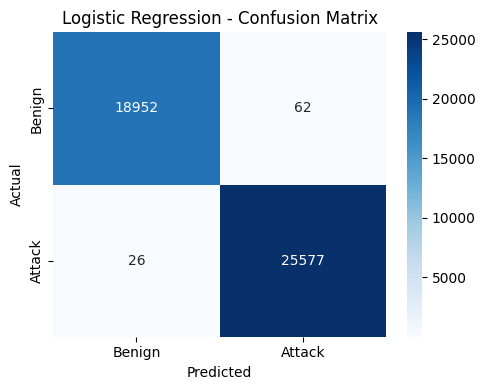


Random Forest Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19014
           1       1.00      1.00      1.00     25603

    accuracy                           1.00     44617
   macro avg       1.00      1.00      1.00     44617
weighted avg       1.00      1.00      1.00     44617



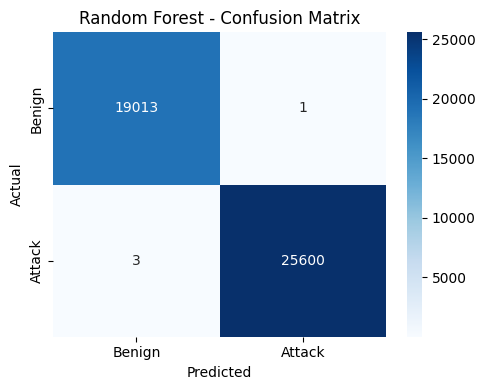

,model,accuracy,precision,recall,f1_score,eval_time_sec
0,Logistic Regression,0.998028,0.997582,0.998984,0.998283,0.409419
1,Random Forest,0.999910,0.999961,0.999883,0.999922,0.873090


In [ ]:
# 10. Evaluate models

import time

# Logistic Regression timing
start = time.perf_counter()
log_metrics, log_cm_path, log_metrics_path = evaluate_model(
    "Logistic Regression",
    log_reg,
    X_test_scaled,
    y_test,
    "logistic_regression"
)
log_time = time.perf_counter() - start

# Random Forest timing
start = time.perf_counter()
rf_metrics, rf_cm_path, rf_metrics_path = evaluate_model(
    "Random Forest",
    rf_model,
    X_test,
    y_test,
    "random_forest"
)
rf_time = time.perf_counter() - start

results_df = pd.DataFrame([
    {
        **{k: v for k, v in log_metrics.items() if k in ["model", "accuracy", "precision", "recall", "f1_score"]},
        "eval_time_sec": log_time
    },
    {
        **{k: v for k, v in rf_metrics.items() if k in ["model", "accuracy", "precision", "recall", "f1_score"]},
        "eval_time_sec": rf_time
    },
])

display(results_df)

training_summary["evaluation"] = {
    "logistic_regression": {
        "accuracy": log_metrics["accuracy"],
        "precision": log_metrics["precision"],
        "recall": log_metrics["recall"],
        "f1_score": log_metrics["f1_score"],
        "eval_time_sec": log_time,
        "metrics_file": str(log_metrics_path),
        "confusion_matrix_figure": str(log_cm_path),
    },
    "random_forest": {
        "accuracy": rf_metrics["accuracy"],
        "precision": rf_metrics["precision"],
        "recall": rf_metrics["recall"],
        "f1_score": rf_metrics["f1_score"],
        "eval_time_sec": rf_time,
        "metrics_file": str(rf_metrics_path),
        "confusion_matrix_figure": str(rf_cm_path),
    },
}

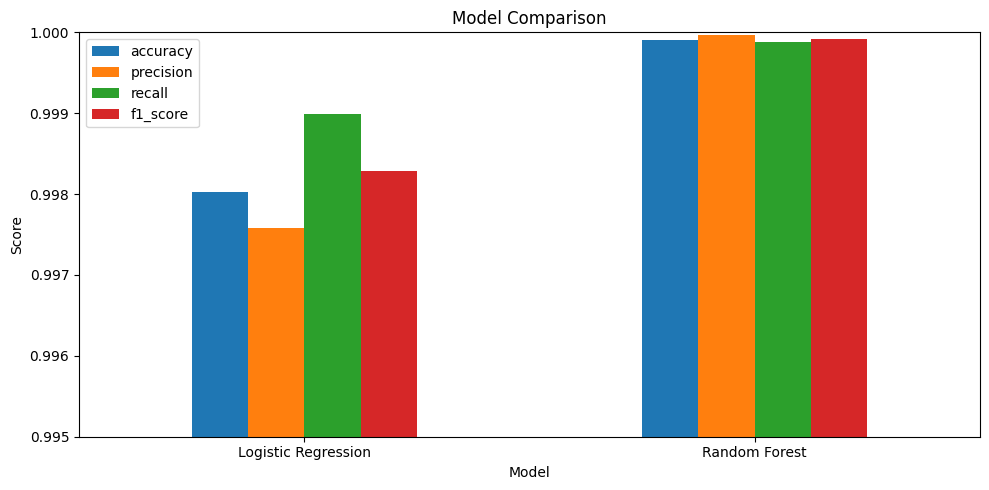

Saved figure: /content/project_outputs/figures/model_comparison.png
Saved metrics table: /content/project_outputs/reports/model_comparison_metrics.csv


In [ ]:
results_path = REPORTS_DIR / "model_comparison_metrics.csv"
results_df.to_csv(results_path, index=False)

ax = results_df.set_index("model")[["accuracy", "precision", "recall", "f1_score"]].plot(
    kind="bar",
    figsize=(10, 5)
)
ax.set_title("Model Comparison")
ax.set_ylabel("Score")
ax.set_xlabel("Model")
plt.xticks(rotation=0)
plt.ylim(0.995, 1.0)
plt.tight_layout()

comparison_plot_path = FIGURES_DIR / "model_comparison.png"
plt.savefig(comparison_plot_path, dpi=200)
plt.show()

print("Saved figure:", comparison_plot_path)
print("Saved metrics table:", results_path)


## Feature Importance

Random Forest feature importance helps explain which network traffic fields matter most.


,feature,importance
8,Fwd Packet Length Mean,0.070292
6,Fwd Packet Length Max,0.069491
53,Avg Fwd Segment Size,0.062946
66,Init_Win_bytes_forward,0.059828
68,act_data_pkt_fwd,0.049976
63,Subflow Fwd Bytes,0.049573
10,Bwd Packet Length Max,0.044894
35,Bwd Header Length,0.037311
11,Bwd Packet Length Min,0.034380
54,Avg Bwd Segment Size,0.033553


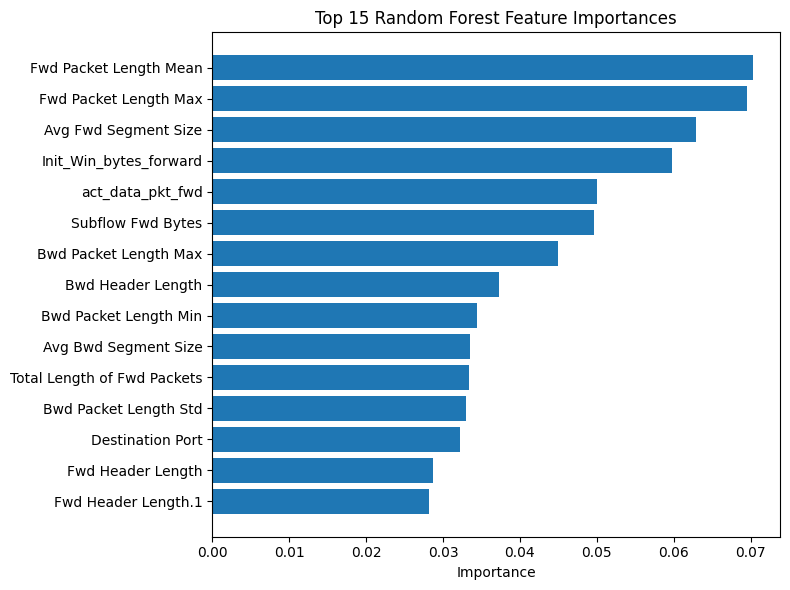

Saved figure: /content/project_outputs/figures/random_forest_feature_importance.png
Saved top-15 feature table: /content/project_outputs/reports/random_forest_top15_feature_importance.csv


In [ ]:
# 11. Feature importance

importances = rf_model.feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

top15_path = REPORTS_DIR / "random_forest_top15_feature_importance.csv"
importance_df.head(15).to_csv(top15_path, index=False)

display(importance_df.head(15))

top_features = importance_df.head(15).sort_values(by="importance")

plt.figure(figsize=(8, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()

feature_importance_path = FIGURES_DIR / "random_forest_feature_importance.png"
plt.savefig(feature_importance_path, dpi=200)
plt.show()

print("Saved figure:", feature_importance_path)
print("Saved top-15 feature table:", top15_path)

training_summary["evaluation"]["random_forest"]["feature_importance_figure"] = str(feature_importance_path)
training_summary["evaluation"]["random_forest"]["top15_feature_importance_csv"] = str(top15_path)


## Save Artifacts (Deprecated)

This section saves:
- processed data
- model artifacts
- metrics
- summary JSON

The Random Forest model is saved as the main deployment artifact for later use in the project app.


In [ ]:
# Save model artifacts

rf_artifact = {
    "model": rf_model,
    "feature_names": feature_names,
    "X_test": X_test,
    "y_test": y_test,
    "target_column": TARGET_COLUMN,
    "label_mapping": {0: "BENIGN", 1: "ATTACK"},
    "metadata": {
        "model_name": "Random Forest",
        "n_estimators": 200,
        "random_state": RANDOM_STATE,
        "test_size": TEST_SIZE,
        "dataset_path": str(raw_csv_path),
    },
}

log_artifact = {
    "model": log_reg,
    "scaler": scaler,
    "feature_names": feature_names,
    "X_test": X_test,
    "y_test": y_test,
    "target_column": TARGET_COLUMN,
    "label_mapping": {0: "BENIGN", 1: "ATTACK"},
    "metadata": {
        "model_name": "Logistic Regression",
        "random_state": RANDOM_STATE,
        "test_size": TEST_SIZE,
        "dataset_path": str(raw_csv_path),
    },
}

rf_model_path = MODELS_DIR / "random_forest_model.joblib"
log_model_path = MODELS_DIR / "logistic_regression_model.joblib"

joblib.dump(rf_artifact, rf_model_path)
joblib.dump(log_artifact, log_model_path)

training_summary["artifacts"] = {
    "processed_csv": str(processed_csv_path),
    "random_forest_model": str(rf_model_path),
    "logistic_regression_model": str(log_model_path),
    "metrics_dir": str(METRICS_DIR),
    "figures_dir": str(FIGURES_DIR),
}

print("Saved:")
print("-", rf_model_path)
print("-", log_model_path)


Saved:
- /content/project_outputs/models/random_forest_model.joblib
- /content/project_outputs/models/logistic_regression_model.joblib


In [ ]:
# Save training summary

summary_path = REPORTS_DIR / "training_summary.json"
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(training_summary, f, indent=4)

print("Training summary saved to:", summary_path)
display(training_summary)


Training summary saved to: /content/project_outputs/reports/training_summary.json


{'dataset': {'raw_file': '/content/drive/MyDrive/cicids2017_subset.csv',
  'raw_shape': [225745, 79],
  'raw_columns_before_cleaning': [' Destination Port',
   ' Flow Duration',
   ' Total Fwd Packets',
   ' Total Backward Packets',
   'Total Length of Fwd Packets',
   ' Total Length of Bwd Packets',
   ' Fwd Packet Length Max',
   ' Fwd Packet Length Min',
   ' Fwd Packet Length Mean',
   ' Fwd Packet Length Std',
   'Bwd Packet Length Max',
   ' Bwd Packet Length Min',
   ' Bwd Packet Length Mean',
   ' Bwd Packet Length Std',
   'Flow Bytes/s',
   ' Flow Packets/s',
   ' Flow IAT Mean',
   ' Flow IAT Std',
   ' Flow IAT Max',
   ' Flow IAT Min',
   'Fwd IAT Total',
   ' Fwd IAT Mean',
   ' Fwd IAT Std',
   ' Fwd IAT Max',
   ' Fwd IAT Min',
   'Bwd IAT Total',
   ' Bwd IAT Mean',
   ' Bwd IAT Std',
   ' Bwd IAT Max',
   ' Bwd IAT Min',
   'Fwd PSH Flags',
   ' Bwd PSH Flags',
   ' Fwd URG Flags',
   ' Bwd URG Flags',
   ' Fwd Header Length',
   ' Bwd Header Length',
   'Fwd Packets/

## Outputs (Deprecated)

This notebook produces the following files:
- processed dataset
- metrics JSON files
- confusion matrix figures
- model comparison figure
- feature importance figure
- trained model artifacts
- training summary JSON
- ZIP package with the outputs


In [ ]:
# Create ZIP package of all outputs

zip_path = OUTPUT_DIR / "project_outputs_package.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for path in OUTPUT_DIR.rglob("*"):
        if path.is_file() and path != zip_path:
            zf.write(path, arcname=path.relative_to(OUTPUT_DIR))

print("Created ZIP package:", zip_path)


Created ZIP package: /content/project_outputs/project_outputs_package.zip
